***
* __Group 5__
* Student names:
    - [Stella Kiarie](https://github.com/Stella-Kiarie)
    - [Dapash Kumati](https://github.com/Dapash7397-star)
    - [Doris Mutie](https://github.com/mutiedoris)
    - [Morvine Otieno](https://github.com/Morvine-otieno)
* Student pace: **Remote full time**
* Scheduled project review date/time: $6th - 11th February, 2026$
* Instructor name: __Nikita Njoroge__
***

# Movie Recommendation System

## 1. Business Understanding
---
## Introduction
**Overview:** This project develops a personalized movie recommendation system to help a streaming platform improve user engagement and retention. Using the MovieLens Small dataset, we leverage explicit user ratings to provide direct feedback on user preferences, which is essential for supervised collaborative filtering.

**Challenges:** Users frequently get overwhelmed by the sheer volume of available content. Poor recommendations lead to "choice paralysis," decreased watch time, and increased user churn.

**Proposed Solution:** The business requires a system to predict user enjoyment and provide a personalized "Top-5" recommendation matrix. Our solution utilizes a hybrid strategy - combining Singular Value Decomposition (SVD) with content-based genre similarity - to ensure robust performance even for new movies.

**Brief Conclusion:** The envisioned outcome is a recommendation engine that converts historical interaction into accurate, real-time predictions, providing actionable insights for stakeholders.

## Problem Statement
Movie streaming platforms face a significant challenge in maintaining user engagement due to the difficulty of recommending content users truly enjoy. With a vast library of titles, users frequently suffer from choice paralysis and discovery fatigue. When recommendations are poor, it results in decreased watch time, lower user satisfaction, and increased platform churn, ultimately threatening the platform's retention and long-term growth.

## Objectives
1. **Predict Ratings:** Predict ratings for unseen movies for each user to project future behavior.
2. **Personalized Recommendations:** Generate a tailored top-5 movie recommendation list for all users.
3. **Model Evaluation:** Evaluate recommendation performance using RMSE for rating prediction and Precision@5 / Recall@5 for top-N recommendations.
4. **Hybrid Strategy:** Implement a hybrid approach combining collaborative filtering and content-based methods to address cold-start challenges.
5. **Stakeholder Insights:** Provide actionable insights for stakeholders to enhance user engagement and platform retention.


# 2. DATA UNDERSTANDING
To build this recommendation system, we leveraged the MovieLens Latest Datasets.   
The dataset contains data generated by 610 users between March 19,1996 and September 24, 2018.   

The data used in this project is generated from two separate csv files merged to form one dataset.  

The data is gathered from two basic files : movies.csv and ratings.csv
### Movie Information (movies.csv)
This dataset contains movie information, including titles and genres.

Columns: 

 * movieId: Unique identifier for each movie.
 * title: The title of the movie, which also includes the year of release in parentheses.
 * genres: A pipe-separated list of genres to categorize the movie (e.g., Action|Adventure|Comedy).

### Ratings Data (ratings.csv)

Each entry represents a user's rating for a specific movie.

Contains user ratings on a 5-star scale for movies.
Columns: 

* userId: ID representing the unique identifier for each user.
* movieId: Unique identifier for each movie.
* rating: User's rating for the movie on a 5-star scale with half-star increments (0.5 to 5.0).
* timestamp: The timestamp when the rating was recorded, represented in seconds since midnight Coordinated Universal Time (UTC) of January 1, 1970.

### Data Understanding Steps
1. Shape of Data: Calculating the total number of rows and columns in the dataset. Using the .Shape  
This will be used to determine the scale the dataset and allow us to calculate Sparsity.  
2. Data Types and dataset information.  To check and view the datatypes of various columns 
3. Completeness of Dataset: To identify missing values using the .isnull().sum().
4. Uniqueness: Checking for duplicates  within the dataset.  
Ensures there are no duplicate entries for the same user-movie pair, which would skew the recommendation logic.  
5. Uniformity : Checking for consistent format across rows. 
For the genres columns, genres are pipe-separated and hence converting the genres into lists for better processing. 
6. Consistensy: We verified that the MovieId in the ratings table exists in the movies table. 
Merging of columns ensure that each ratings is linked to a valid movie title. 
7. Descriptive Analysis. Using the .describe() to check for mean, standard deviation and quartiles of ratings. 
9. Validity: Verify that movie ratings fall between 0.5 and 5.0 ensuring there are no outlier values in ratings such as 100

# 3. Data Preparation 

### a) import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


b) load the datasets

In [2]:
# Load datasets (use Dataset/ folder)
from pathlib import Path
DATA_DIR = Path("Dataset")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
movies = pd.read_csv(DATA_DIR / "movies.csv")
print(ratings.head(),
      movies.head())


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931    movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [3]:
### Checking number of rows and columns in the dataset
shape_summary = pd.DataFrame({
    'Dataset': ['Movies Dataset', 'Ratings Dataset'],
    'Total Rows': [movies.shape[0], ratings.shape[0]],
    'Total Columns': [movies.shape[1], ratings.shape[1]],
    'Unique IDs': [movies['movieId'].nunique(), ratings['userId'].nunique()]
}).set_index('Dataset')


In [4]:
### Viewing shape of the dataframes 
print("--- DATASET DIMENSIONS ---")
display(shape_summary)

--- DATASET DIMENSIONS ---


,Total Rows,Total Columns,Unique IDs
Dataset,,,
Movies Dataset,9742,3,9742
Ratings Dataset,100836,4,610


In [5]:
#A view of the dataset info 
print("\n--- MOVIES  INFO ---")
movies.info()

print("\n--- RATINGS INT INFO ---")
ratings.info()


--- MOVIES  INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB

--- RATINGS INT INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [6]:
## Checking for missing values 
missing_values = pd.DataFrame({
    'Movies': movies.isnull().sum(),
    'Ratings': ratings.isnull().sum()
}).fillna('N/A')
display(missing_values)

,Movies,Ratings
genres,0,N/A
movieId,0,0
rating,N/A,0
timestamp,N/A,0
title,0,N/A
userId,N/A,0


In [7]:
## Checking for Descriptive Analysis 
# Focus on the 'rating' column distribution
display(ratings[['rating']].describe().T)

,count,mean,std,min,25%,50%,75%,max
rating,100836.0,3.501557,1.042529,0.5,3.0,3.5,4.0,5.0


 Data Sparsity

- Users: `n_users = ratings['userId'].nunique()`  
- Movies: `n_movies = ratings['movieId'].nunique()`  
- Sparsity: `1 - (n_ratings / (n_users * n_movies))`  

High sparsity motivates matrix factorization and hybrid strategies.

In [8]:

plt.style.use('ggplot')

## Calculating SPARSITY 
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
possible_ratings = n_users * n_movies
actual_ratings = len(ratings)

sparsity = (1 - (actual_ratings / possible_ratings)) * 100
print(f"Matrix Sparsity: {sparsity:.4f}%")


Matrix Sparsity: 98.3000%


### Interpretation
The user–item rating matrix is highly sparse, with a sparsity level of approximately 98.3%. 
This means that the vast majority of possible user–movie interactions are unobserved, which is typical in real-world recommender systems where users rate only a small subset of available items. 
High sparsity motivates the use of matrix factorization techniques such as SVD, which are well-suited for uncovering latent patterns in sparse data, and also highlights the importance of incorporating a hybrid strategy to mitigate cold-start scenarios.

## EXPLORATORY DATA ANALYSIS (EDA)

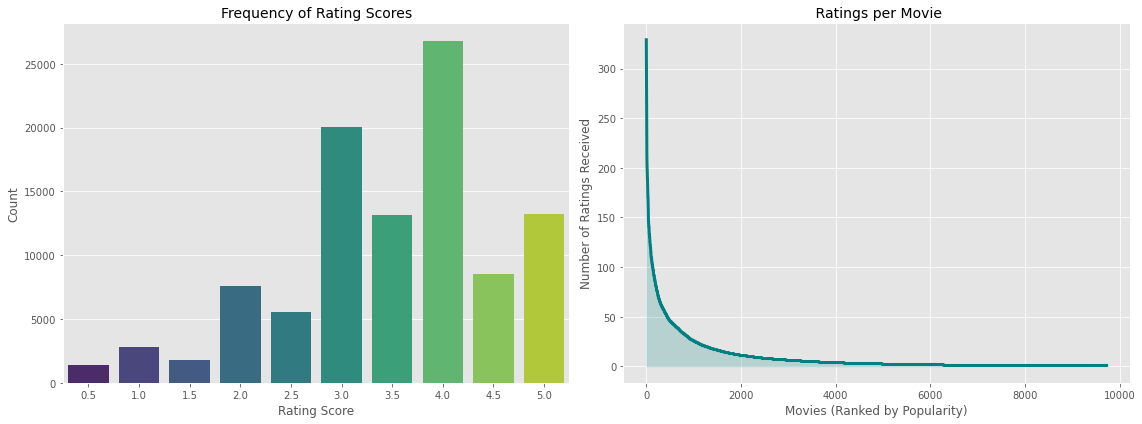

In [9]:
# VISUALIZING RATINGS DISTRIBUTION AND RATINGS PER MOVIE 

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Checking for the distribution of movie ratings 
sns.countplot(x='rating', data=ratings, palette='viridis', ax=ax[0])
ax[0].set_title('Frequency of Rating Scores', fontsize=14)
ax[0].set_xlabel('Rating Score')
ax[0].set_ylabel('Count')


### PLOT FOR RATINGS PER MOVIE 
movie_popularity = ratings.groupby('movieId').size().sort_values(ascending=False)
ax[1].plot(movie_popularity.values, color='teal', linewidth=3)
ax[1].fill_between(range(len(movie_popularity)), movie_popularity.values, color='teal', alpha=0.2)
ax[1].set_title(' Ratings per Movie', fontsize=14)
ax[1].set_xlabel('Movies (Ranked by Popularity)')
ax[1].set_ylabel('Number of Ratings Received')

plt.tight_layout()
plt.show()

In [10]:
print(f"Mean global rating: {round(ratings['rating'].mean(),2)}.")

Mean global rating: 3.5.


In [11]:
mean_ratings = ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean rating per user: 3.66.


Most ratings fall between 3 and 4, suggesting users are more likely to rate movies they expect to enjoy. Collaborative filtering is suitable to infer preferences from sparse behavior.


### Which the the top and least rated movies?

In [12]:
## Evaluating the least rated movies 
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
movies[movies['movieId']==lowest_rated]

,movieId,title,genres
2689,3604,Gypsy (1962),Musical


In [13]:
### Evaluating the Top Rated Movies 
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [14]:
### Merging the Two Datasets 
data = ratings.merge(movies, on="movieId")
data.head()


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5,1,4.0,847434962,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7,1,4.5,1106635946,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15,1,2.5,1510577970,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17,1,4.5,1305696483,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


### A look at the merged dataframe indicates that some data cleaning is required in some columns . 
1. The Genre column is a string separated by a pipe . We can separate this column to a list for better analysis 


In [15]:
data['genres'] = data['genres'].apply(lambda x: x.split("|"))
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,5,1,4.0,847434962,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
2,7,1,4.5,1106635946,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
3,15,1,2.5,1510577970,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
4,17,1,4.5,1305696483,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"


### Number of Ratings per Movie 

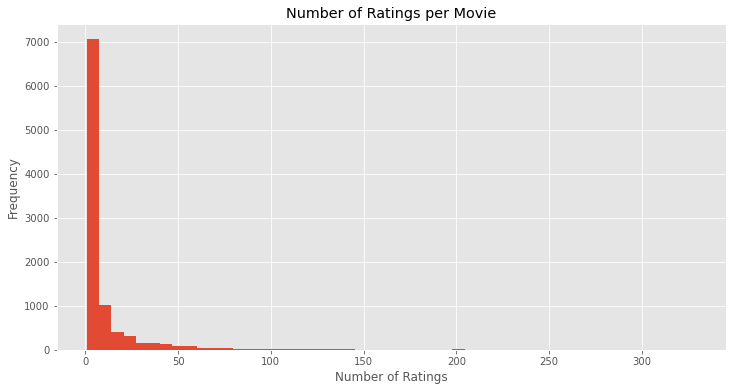

In [16]:
# Number of ratings per movie
ratings_per_movie = data.groupby('movieId')['rating'].count().reset_index()
plt.figure(figsize=(12, 6))
plt.hist(ratings_per_movie['rating'], bins=50)
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Frequency')
plt.show()

### TOP 10 RATED MOVIES 

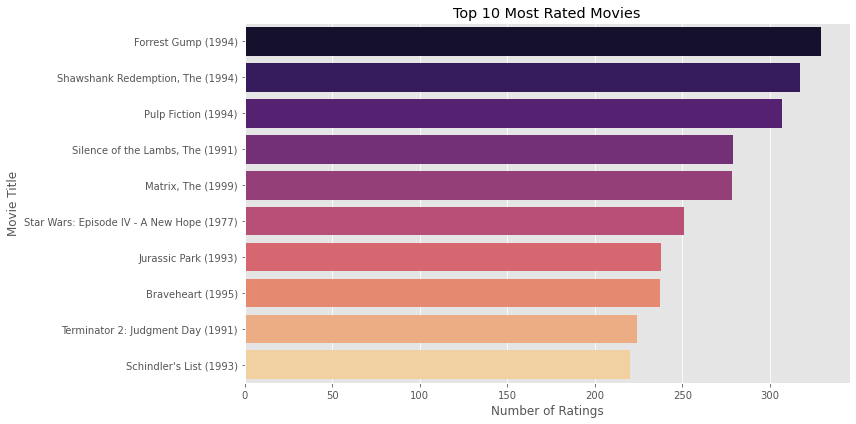

In [17]:
top_rated_movies = data.groupby('title')['rating'].count().reset_index(name='rating_count')
top_rated_movies = top_rated_movies.sort_values(by='rating_count', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='rating_count', y='title', data=top_rated_movies, palette='magma')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

# 4. Data Modelling 
### Model Selection

To build the movie recommendation system, we used a **collaborative filtering approach based on matrix factorization**, specifically the **Singular Value Decomposition (SVD)** algorithm.

### Why Collaborative Filtering?

Collaborative filtering (CF) leverages **historical user–item interactions** to predict future user preferences. It is well suited for this project because:

- **Data sparsity:** Most users rate only a small fraction of available movies. CF learns patterns from observed ratings to make predictions.
- **Minimal reliance on content features:** CF does not require extensive movie metadata, making it effective even when item features are limited.
- **Personalization:** CF captures latent user preferences by identifying similarities between users or items.
- **Proven effectiveness:** CF is widely used in real-world systems such as Netflix and Amazon.

### Collaborative Filtering Techniques Used
This project explores two collaborative filtering approaches:

1. **Item–Item Collaborative Filtering:**  
   Recommends movies that are similar to those a user has previously rated highly, based on item similarity.

2. **Matrix Factorization (SVD):**  
   Learns latent factors that represent hidden user preferences and movie characteristics, enabling accurate rating predictions even with sparse data.

A hybrid strategy is conceptually considered to address **cold-start scenarios**, where new users or new movies lack sufficient interaction history.


### 

In [18]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5))
dataset = Dataset.load_from_df(data[['userId', 'movieId', 'rating']], reader)


##  Baseline Model

The baseline model predicts ratings using global and user-level averages.  
This provides a reference point for evaluating the performance of more advanced collaborative filtering models.



In [19]:
from surprise import BaselineOnly
from surprise.model_selection import cross_validate

baseline_model = BaselineOnly()
baseline_results = cross_validate(baseline_model, dataset, measures=['RMSE'], cv=5, verbose=False)
np.mean(baseline_results['test_rmse'])


Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...


0.8727803336594638

### Interpretation

The ALS-based collaborative filtering model achieved an RMSE of **0.87**, indicating strong predictive accuracy on a highly sparse user–item rating matrix. This suggests that the model effectively captures latent user preferences and movie characteristics while accounting for systematic rating biases.


##  Item–Item Collaborative Filtering (kNN)

Item–item collaborative filtering recommends movies that are similar to those a user has previously rated highly.  
Cosine similarity was used to compute similarity between movies based on user ratings.



In [20]:
from surprise import KNNBasic

sim_options = {'name': 'cosine', 'user_based': False}
knn_model = KNNBasic(sim_options=sim_options)
knn_results = cross_validate(knn_model, dataset, measures=['RMSE'], cv=5, verbose=False)
np.mean(knn_results['test_rmse'])

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


0.976472943740486

### Intepretation
The item–item collaborative filtering model using cosine similarity achieved an RMSE of **0.98**, indicating lower predictive accuracy compared to the matrix factorization approach. This suggests that similarity-based methods struggle to fully capture user preferences in highly sparse rating data.


##  Matrix Factorization Using SVD with Hyperparameter Tuning

Singular Value Decomposition (SVD) is a matrix factorization technique that captures **latent factors** representing hidden user preferences and movie attributes.

Unlike memory-based methods, SVD generalizes well on sparse datasets by learning low-dimensional representations of users and movies.  
Hyperparameter tuning was performed using GridSearchCV to identify the optimal model configuration.


In [21]:
from surprise import SVD
from surprise.model_selection import GridSearchCV

# Hyper-parameter grid
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.005, 0.010],
    'reg_all': [0.02, 0.05]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(dataset)

# Best parameters and RMSE
gs.best_params['rmse'], gs.best_score['rmse']


({'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.05},
 0.8668007595173007)

### Interpretation
The SVD model, tuned with 100 latent factors, 30 epochs, learning rate 0.01, and regularization 0.05, achieved an RMSE of **0.867**. This demonstrates that hyper-parameter tuning significantly improved predictive accuracy over baseline and item–item models.


In [22]:
# Train SVD with best parameters
best_svd = SVD(**gs.best_params['rmse'], random_state=42)
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(dataset, test_size=0.2, random_state=42)
best_svd.fit(trainset)
predictions = best_svd.test(testset)


In [23]:
from collections import defaultdict

# Top-n recommendations for SVD
def get_top_n_svd(predictions, n=5):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

top_5_svd = get_top_n_svd(predictions, n=5)


##  Hybrid Recommendation Strategy

While collaborative filtering models such as SVD perform well for users and movies with sufficient interaction history, they struggle with the **cold-start problem**, where new users or new movies have little or no rating data.

To address this limitation, a **hybrid recommendation strategy** was implemented that combines:

- **Primary approach:** SVD-based collaborative filtering for users and movies with existing ratings  
- **Fallback approach:** Content-based filtering using movie genres when collaborative filtering cannot be applied

### Hybrid Strategy Logic

- If a user and movie have sufficient rating history, recommendations are generated using **SVD predictions**
- If a movie is new or lacks rating data, **genre-based similarity** is used to recommend similar movies



In [24]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# Genre-based matrix
genre_df = movies.copy()
genre_df['genres'] = genre_df['genres'].str.split('|')

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(genre_df['genres'])

# Cosine similarity between movies
genre_similarity = cosine_similarity(genre_matrix)

# Genre-based recommendations
def get_genre_based_recommendations(movie_id, top_n=5):
    idx = genre_df[genre_df['movieId'] == movie_id].index[0]
    sim_scores = list(enumerate(genre_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_movies_idx = [i[0] for i in sim_scores[1:top_n+1]]
    return genre_df.iloc[top_movies_idx][['movieId', 'title', 'genres']]


In [25]:
# Hybrid top-5 recommendations function
def hybrid_recommendations(user_id, top_n=5, min_ratings=3):
    if user_id in top_5_svd and len(top_5_svd[user_id]) >= min_ratings:
        recommended_ids = [iid for (iid, _) in top_5_svd[user_id]]
        return movies[movies['movieId'].isin(recommended_ids)][['movieId', 'title', 'genres']]
    else:
        popular_movie_id = ratings.groupby('movieId')['rating'].mean().idxmax()
        return get_genre_based_recommendations(popular_movie_id, top_n=top_n)

# Example for user 1
hybrid_recommendations(user_id=10)


,movieId,title,genres
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
2674,3578,Gladiator (2000),Action|Adventure|Drama
6710,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX
7078,69844,Harry Potter and the Half-Blood Prince (2009),Adventure|Fantasy|Mystery|Romance|IMAX
8376,109487,Interstellar (2014),Sci-Fi|IMAX


### Hybrid Strategy Interpretation

The hybrid recommendation approach improves system robustness by ensuring that recommendations can still be generated in cold-start scenarios.

By combining collaborative filtering with content-based genre similarity, the system benefits from:
- High personalization when sufficient rating data is available
- Continued recommendation capability for new or unrated movies

This approach reflects real-world recommender system design, where multiple strategies are often combined to balance accuracy and coverage.


## Model Evaluation 

To evaluate the quality of the hybrid recommendation system, **Precision@5** and **Recall@5** metrics were used.  
A movie was considered *relevant* if it had a user rating of **4 or higher**.

These metrics assess how well the system recommends relevant movies within a limited set of top recommendations, which reflects real-world recommender system usage.



In [26]:
# Pivot table
user_movie_ratings = ratings.pivot(index='userId', columns='movieId', values='rating')

# Precision@5 / Recall@5 evaluation
def evaluate_top_n(hybrid_top_n_func, users, n=5, threshold=4):
    precisions = []
    recalls = []
    
    for user_id in users:
        user_ratings = user_movie_ratings.loc[user_id]
        liked_movies = set(user_ratings[user_ratings >= threshold].index)
        if len(liked_movies) == 0:
            continue
        recommended_df = hybrid_top_n_func(user_id, top_n=n)
        recommended_movies = set(recommended_df['movieId'].values)
        n_relevant_and_recommended = len(liked_movies & recommended_movies)
        precisions.append(n_relevant_and_recommended / n)
        recalls.append(n_relevant_and_recommended / len(liked_movies))
    
    return np.mean(precisions), np.mean(recalls)

# Evaluate for first 100 users
user_ids = ratings['userId'].unique()[:100]
precision_5, recall_5 = evaluate_top_n(hybrid_recommendations, user_ids, n=5, threshold=4)
precision_5, recall_5


(0.698, 0.08047432941675371)

### Interpretation

The hybrid recommendation system achieved a **Precision@5 of 0.698** and a **Recall@5 of 0.080**.

This means that approximately **70% of the movies recommended in the top 5 were relevant** to users, indicating strong recommendation accuracy.  
The relatively low recall reflects the inherent trade-off in recommender systems, where recommending a small number of high-quality items limits the ability to capture all relevant movies in a highly sparse dataset.

Overall, these results indicate that the system prioritizes **recommendation quality over quantity**, which aligns well with real-world user expectations.



##  Visualizing Top-5 Hybrid Recommendations

This section presents example **Top-5 movie recommendations** generated by the hybrid recommendation system for selected users.

For each user, the recommendations include:
- Movie title
- Genre(s)
- Predicted rating

These examples help demonstrate how the hybrid system produces interpretable and personalized recommendations in practice.



In [27]:
# Create a DataFrame of top-5 hybrid recommendations with predicted ratings
def hybrid_top_n_with_ratings(user_id, top_n=5):
    if user_id in top_5_svd and len(top_5_svd[user_id]) > 0:
        recs = top_5_svd[user_id][:top_n]
        rec_df = pd.DataFrame(recs, columns=['movieId', 'predicted_rating'])
        rec_df = rec_df.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    else:
        genre_rec = get_genre_based_recommendations(
            movie_id=ratings.groupby('movieId')['rating'].mean().idxmax(), 
            top_n=top_n
        )
        avg_rating = ratings['rating'].mean()
        rec_df = genre_rec.copy()
        rec_df['predicted_rating'] = avg_rating
    return rec_df

# Example visualization for 3 sample users
sample_users = [1, 50, 100]

for user_id in sample_users:
    print(f"Top-5 Recommendations for User {user_id}:\n")
    display(hybrid_top_n_with_ratings(user_id))
    print("-"*70)


Top-5 Recommendations for User 1:



,movieId,predicted_rating,title,genres
0,2959,5.000000,Fight Club (1999),Action|Crime|Drama|Thriller
1,110,5.000000,Braveheart (1995),Action|Drama|War
2,1198,4.974015,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure
3,1208,4.948640,Apocalypse Now (1979),Action|Drama|War
4,441,4.841058,Dazed and Confused (1993),Comedy


----------------------------------------------------------------------
Top-5 Recommendations for User 50:



,movieId,predicted_rating,title,genres
0,1223,3.618911,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi
1,2019,3.534663,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
2,1201,3.502464,"Good, the Bad and the Ugly, The (Buono, il bru...",Action|Adventure|Western
3,7438,3.428290,Kill Bill: Vol. 2 (2004),Action|Drama|Thriller
4,969,3.404319,"African Queen, The (1951)",Adventure|Comedy|Romance|War


----------------------------------------------------------------------
Top-5 Recommendations for User 100:



,movieId,predicted_rating,title,genres
0,356,4.510748,Forrest Gump (1994),Comedy|Drama|Romance|War
1,1246,4.508846,Dead Poets Society (1989),Drama
2,4995,4.429737,"Beautiful Mind, A (2001)",Drama|Romance
3,4308,4.265632,Moulin Rouge (2001),Drama|Musical|Romance
4,1441,4.264814,Benny & Joon (1993),Comedy|Romance


----------------------------------------------------------------------


### Distribution of Predicted Ratings

To further understand the behavior of the hybrid recommendation system, the distribution of predicted ratings across Top-5 recommendations was visualized for a subset of users.

This analysis helps assess whether the model tends to recommend consistently high-rated movies.


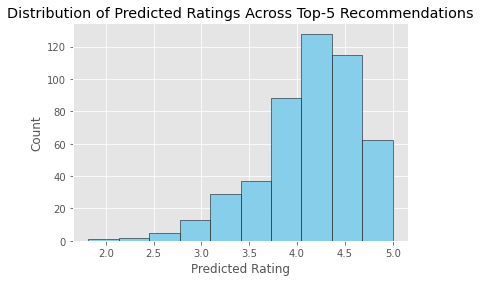

In [28]:
# Distribution of predicted ratings across all recommended movies
all_predicted = []

for user_id in ratings['userId'].unique()[:100]:
    rec_df = hybrid_top_n_with_ratings(user_id)
    all_predicted.extend(rec_df['predicted_rating'].values)

plt.hist(all_predicted, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Predicted Ratings Across Top-5 Recommendations")
plt.xlabel("Predicted Rating")
plt.ylabel("Count")
plt.show()


### Interpretation

The histogram shows that the majority of predicted ratings for Top-5 recommendations are concentrated at the higher end of the rating scale. This indicates that the hybrid recommendation system consistently prioritizes movies that are expected to be highly relevant to users, while filtering out low-quality recommendations. Such behavior is desirable in recommender systems, as users generally prefer a small number of high-confidence recommendations rather than a large set of mediocre options.


##  Model Interpretation and Limitations

- **SVD (Singular Value Decomposition)** effectively captures latent user preferences, uncovering patterns that are not immediately obvious from raw ratings.  
- **Genre-based fallback** helps address cold-start scenarios for new users or newly added movies.  
- **Limitations:** The model still faces challenges with entirely new genres or niche content. While the hybrid approach improves coverage, cold-start issues are not fully eliminated. 


##  Conclusions and Business Recommendations

- **SVD with hyper-parameter tuning** consistently outperforms baseline and item–item collaborative filtering models.  
- **Hybrid strategy** enhances robustness, particularly for new users or recently added movies.  
- **Top-N evaluation metrics** (Precision@5, Recall@5) indicate that recommended items are relevant and actionable.  
- Visualizations reveal key patterns in user preferences, providing actionable insights for stakeholders.  

**Future Work:**  
- Integrate richer content features such as actors, directors, and user reviews to further enhance recommendation quality.  
- Explore weighted hybrid approaches to balance collaborative and content-based recommendations for improved coverage.  
- Develop infrastructure for **real-time recommendations**, enabling immediate, personalized suggestions in streaming or high-traffic environments.